# Spaceflight–Disease Network Separation Pipeline
**NetMedPy · PCNet 2.2 · Query: Spaceflight Module**

Measures network separation (Menche et al. 2015) between the spaceflight gene
module and all OMIM/GWAS disease modules.

**Prerequisite:** Run `1_disease_module_curation.ipynb` first.
Required input file: `data/processed/gene_modules/gene_modules.pkl`

**Workflow:**
- Step 1 — Imports, helpers, and load interactome + disease gene sets
- Step 2 — Pre-compute all-pair shortest path distances (cached)
- Step 2b — Benchmark: auto-configure Ray workers and estimate runtime
- Step 3 — Run separation screening (Ray-parallel, checkpointed)
- Step 4 — Build results table with BH-FDR correction
- Step 4b — Empirical FDR calibration (diagnostic)
- Step 5 — Summary statistics

**Outputs written to `data/output/`:**
```
data/
  output/
    sp_distance.pkl
    benchmark.json
    checkpoints/<disease_name>.pkl
    disease_separation_results.pkl
    run_timelog.json
    csv/
      separation_summary.csv
      separation_significant.csv
    fdr_calibration_empirical.png
```

**Visualisations** are produced in `3_spaceflight_disease_visualization.ipynb`.


## Step 1 — Imports, Helpers, and Data Loading

All imports and shared helpers are consolidated here. `load()` / `save()` and
`disease_to_filename()` are defined once and reused throughout this notebook
and the generated `run_screening.py` script.

Loads the PCNet 2.2 interactome and the merged disease gene dictionary.
Disease modules are re-filtered to ≥ 20 genes in the interactome. The
spaceflight module is separated from the target set.

> **Note on path constants:** `PPI_PATH` and `DIST_PATH` are passed *as
> strings* into Ray remote functions so each worker can open them independently.
> This avoids the copy-on-write OOM that occurs with `ray.put()` on large
> objects; Linux page cache keeps both files hot after the first worker loads
> them.


In [1]:
import networkx as nx
import numpy as np
import pandas as pd
import netmedpy
import pickle
import os
import time
import json
import subprocess
import sys
import psutil
import ray
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy import stats
from statsmodels.stats.multitest import multipletests
from netmedpy import separation_z_score

# ── Path constants ────────────────────────────────────────────────────────────
PPI_PATH       = "data/processed/ppi/ppi_network.pkl"
DISEASE_PATH   = "data/processed/gene_modules/gene_modules.pkl"
DIST_PATH      = "data/output/sp_distance.pkl"
BENCH_PATH     = "data/output/benchmark.json"
RESULTS_CACHE  = "data/output/disease_separation_results.pkl"
CHECKPOINT_DIR = "data/output/checkpoints"
RUN_LOG_PATH   = "data/output/run_timelog.json"
QUERY_KEY      = "spaceflight"

# ── Directory setup ───────────────────────────────────────────────────────────
os.makedirs("data/output", exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# ── Shared helpers (load, save, disease_to_filename, simulate_parallel_runtime,
# ── fit_empirical_model) are imported from utils.py to avoid duplication.
from utils import (
    load, save,
    disease_to_filename as _disease_to_filename,
    simulate_parallel_runtime,
    fit_empirical_model,
)

def disease_to_filename(name: str) -> str:
    """Wrapper that injects the local CHECKPOINT_DIR constant."""
    return _disease_to_filename(name, CHECKPOINT_DIR)

# ── Load interactome ──────────────────────────────────────────────────────────
if not os.path.exists(PPI_PATH):
    raise FileNotFoundError(
        f"{PPI_PATH} not found. Run Step 1 of 1_disease_module_curation.ipynb first."
    )
ppi = load(PPI_PATH)
print(f"Interactome nodes : {ppi.number_of_nodes():,}")
print(f"Interactome edges : {ppi.number_of_edges():,}")

# ── Load disease gene sets ────────────────────────────────────────────────────
if not os.path.exists(DISEASE_PATH):
    raise FileNotFoundError(
        f"{DISEASE_PATH} not found. Run 1_disease_module_curation.ipynb first."
    )
disease_genes_raw = load(DISEASE_PATH)
ppi_nodes = set(ppi.nodes())
disease_genes = {
    d: set(g) & ppi_nodes
    for d, g in disease_genes_raw.items()
    if len(set(g) & ppi_nodes) >= 20
}
print(f"\nDisease gene sets loaded : {len(disease_genes)}")

# ── Separate query module ─────────────────────────────────────────────────────
if QUERY_KEY not in disease_genes:
    raise KeyError(
        f"'{QUERY_KEY}' not found in {DISEASE_PATH}. "
        "Run Step 7 of 1_disease_module_curation.ipynb to inject the spaceflight module."
    )

query_genes     = disease_genes[QUERY_KEY]
target_diseases = {d: g for d, g in disease_genes.items() if d != QUERY_KEY}

print(f"Query module         : {QUERY_KEY}")
print(f"Query genes in PPI   : {len(query_genes)}")
print(f"Target diseases      : {len(target_diseases)}")

disease_sizes = pd.Series({d: len(g) for d, g in target_diseases.items()})
print(f"\nTarget gene set sizes:")
print(f"  Min    : {disease_sizes.min()}")
print(f"  Median : {disease_sizes.median():.0f}")
print(f"  Max    : {disease_sizes.max()}")
print(f"  Mean   : {disease_sizes.mean():.0f}")


Interactome nodes : 18,554
Interactome edges : 3,323,926

Disease gene sets loaded : 266
Query module         : spaceflight
Query genes in PPI   : 1166
Target diseases      : 265

Target gene set sizes:
  Min    : 20
  Median : 56
  Max    : 2597
  Mean   : 167


## Step 1b — Checkpoint Validation

Cross-checks the existing checkpoint files against `target_diseases` before
the screening loop begins. Any disease with a missing checkpoint is reported;
a count mismatch here means the final merged results will be incomplete.

> Run this cell after Step 1 and before Step 3. Re-run at any time to verify
> the checkpoint directory is consistent with the current disease set.


In [2]:
# ── Checkpoint validation (Recommendation 3) ──────────────────────────────────
# Cross-check existing checkpoints against target_diseases so that silent
# under-counting in the final results is caught before screening starts.

existing_checkpoints = {
    d for d in target_diseases
    if os.path.exists(disease_to_filename(d))
}
missing_checkpoints = sorted(set(target_diseases) - existing_checkpoints)

print("=" * 60)
print("CHECKPOINT VALIDATION")
print("=" * 60)
print(f"Target diseases        : {len(target_diseases)}")
print(f"Existing checkpoints   : {len(existing_checkpoints)}")
print(f"Missing checkpoints    : {len(missing_checkpoints)}")
print()

if not missing_checkpoints:
    print("✅ All checkpoints present — merge will be complete.")
else:
    print("⚠️  The following diseases have no checkpoint yet (will be computed in Step 3):")
    for _d in missing_checkpoints[:20]:
        print(f"   - {_d}")
    if len(missing_checkpoints) > 20:
        print(f"   ... and {len(missing_checkpoints) - 20} more")
    print()
    print("Action: Run Step 3 to compute missing diseases before merging.")


CHECKPOINT VALIDATION
Target diseases        : 265
Existing checkpoints   : 265
Missing checkpoints    : 0

✅ All checkpoints present — merge will be complete.


## Step 2 — Pre-Compute All-Pair Shortest Path Distances

Uses `netmedpy.all_pair_distances` with `distance='shortest_path'` across
30% of available CPU cores. Cached to `data/output/sp_distance.pkl` — loaded
automatically on subsequent runs (first run typically 10–30 min).


In [3]:
N_PROCS = max(1, int(os.cpu_count() * 0.3))
print(f"Using {N_PROCS} of {os.cpu_count()} logical cores")

if os.path.exists(DIST_PATH):
    print(f"Loading cached distances ({time.ctime(os.path.getmtime(DIST_PATH))}) ...")
    sp_distance = load(DIST_PATH)
    print("Distances loaded. ✅")
else:
    print("Computing all-pair shortest path distances...")
    t0 = time.time()
    sp_distance = netmedpy.all_pair_distances(
        ppi,
        distance="shortest_path",
        n_processors=N_PROCS,
        n_tasks=1000,
    )
    save(sp_distance, DIST_PATH)
    print(f"Done in {(time.time()-t0)/60:.1f} min — cached to {DIST_PATH} ✅")


Using 15 of 52 logical cores
Loading cached distances (Mon Mar  9 15:30:10 2026) ...
Distances loaded. ✅


## Step 2b — Benchmark: Auto-Configure Workers & Estimate Runtime

Measures available RAM and per-worker memory footprint via an isolated
subprocess, then fits **both linear and quadratic runtime models** across five
representative gene-set sizes (min / Q1 / median / Q3 / max). The quadratic
model is selected when it improves R² by > 0.02 over linear.

| Variable | Description |
|---|---|
| `N_WORKERS` | Ray workers — RAM-limited, capped at `cpu_count - 1` |
| `N_ITER` | Permutations per disease — 1 000 for testing; 10 000 for publication |
| `runtime_model` | `"linear"` or `"quadratic"` — selected automatically |
| `runtime_alpha2` | Quadratic coefficient (only when quadratic model is used) |

Results saved to `data/output/benchmark.json` and consumed automatically by
Step 3.

> **Tip:** Delete `data/output/benchmark.json` and re-run this cell after
> rebooting, changing available RAM, or significantly changing `N_ITER`.


In [4]:
N_ITER    = 10000   # permutations for full run
RAM_SAFETY = 0.80

if os.path.exists(BENCH_PATH):
    with open(BENCH_PATH) as f:
        benchmark_config = json.load(f)
    n_workers      = benchmark_config["N_WORKERS"]
    runtime_alpha  = benchmark_config.get("runtime_alpha")
    runtime_beta   = benchmark_config.get("runtime_beta")
    runtime_alpha2 = benchmark_config.get("runtime_alpha2", None)
    print(f"Existing benchmark found ({benchmark_config.get('benchmarked_on', 'unknown')}) — skipping.")
    print(f"  N_WORKERS = {n_workers}   N_ITER = {benchmark_config['N_ITER']}")
    print("  Delete data/output/benchmark.json to re-run.")
else:
    print("=" * 60)
    print("BENCHMARK — Auto-configure N_WORKERS")
    print("=" * 60)

    mem          = psutil.virtual_memory()
    total_gb     = mem.total     / 1024**3
    available_gb = mem.available / 1024**3
    print(f"\nSystem RAM    : {total_gb:.1f} GB")
    print(f"Available now : {available_gb:.1f} GB")
    print(f"Safety budget : {available_gb * RAM_SAFETY:.1f} GB")

    print("\nMeasuring RAM per worker (isolated subprocess)...")
    measure_script = """
import pickle, psutil, os, json
proc   = psutil.Process(os.getpid())
before = proc.memory_info().rss
with open('data/processed/ppi/ppi_network.pkl', 'rb') as f:
    ppi = pickle.load(f)
with open('data/output/sp_distance.pkl', 'rb') as f:
    sp  = pickle.load(f)
after = proc.memory_info().rss
print(json.dumps({'rss_gb': (after - before) / 1024**3}))
"""
    try:
        result = subprocess.run(
            [sys.executable, "-c", measure_script],
            capture_output=True, text=True, timeout=300,
        )
        ram_per_worker_gb = json.loads(result.stdout.strip())["rss_gb"]
    except Exception as e:
        print(f"RAM measurement failed ({e}) — using 3.5 GB default")
        ram_per_worker_gb = 3.5

    ram_per_worker_gb *= 1.10
    budget_gb = available_gb * RAM_SAFETY
    n_workers = max(1, min(int(budget_gb / ram_per_worker_gb), os.cpu_count() - 1))
    print(f"\nRAM per worker (+overhead) : {ram_per_worker_gb:.2f} GB")
    print(f"Recommended N_WORKERS      : {n_workers}")

    print("\nBenchmarking size-adjusted runtime (n_iter=100)...")
    sorted_diseases = sorted(target_diseases.items(), key=lambda x: len(x[1]))
    sample_set = [
        sorted_diseases[0],
        sorted_diseases[len(sorted_diseases) // 4],
        sorted_diseases[len(sorted_diseases) // 2],
        sorted_diseases[3 * len(sorted_diseases) // 4],
        sorted_diseases[-1],
    ]
    bench_results = []
    for name, genes in sample_set:
        t0 = time.time()
        _ = separation_z_score(ppi, query_genes, genes, sp_distance,
                               null_model="log_binning", n_iter=100)
        elapsed = time.time() - t0
        bench_results.append((len(genes), elapsed))
        print(f"{name:30s} | size={len(genes):4d} | {elapsed:.1f}s")

    bm_sizes = np.array([r[0] for r in bench_results])
    bm_times = np.array([r[1] for r in bench_results])

    lin_coeffs              = np.polyfit(bm_sizes, bm_times, 1)
    runtime_alpha, runtime_beta = float(lin_coeffs[0]), float(lin_coeffs[1])
    lin_pred  = runtime_alpha * bm_sizes + runtime_beta
    ss_tot    = np.sum((bm_times - bm_times.mean()) ** 2)
    r2_linear = 1 - np.sum((bm_times - lin_pred)**2) / ss_tot if ss_tot > 0 else 0

    quad_coeffs   = np.polyfit(bm_sizes, bm_times, 2)
    # Unpack directly into the canonical names — no intermediate _a2/_a1/_b aliases
    runtime_alpha2, runtime_alpha, runtime_beta = (
        float(quad_coeffs[0]), float(quad_coeffs[1]), float(quad_coeffs[2])
    )
    quad_pred   = runtime_alpha2 * bm_sizes**2 + runtime_alpha * bm_sizes + runtime_beta
    r2_quad     = 1 - np.sum((bm_times - quad_pred)**2) / ss_tot if ss_tot > 0 else 0
    use_quadratic = (r2_quad - r2_linear) > 0.02

    print(f"\nLinear    R²={r2_linear:.4f} : t ≈ {runtime_alpha:.6f}·size + {runtime_beta:.2f}")
    print(f"Quadratic R²={r2_quad:.4f} : t ≈ {runtime_alpha2:.8f}·size² + {runtime_alpha:.6f}·size + {runtime_beta:.2f}")
    print(f"Selected  : {'Quadratic ✅' if use_quadratic else 'Linear ✅'}")

    if not use_quadratic:
        # Linear model selected — discard quadratic coefficient and restore
        # the clean linear coefficients (quadratic polyfit overwrote them above).
        runtime_alpha2 = None
        runtime_alpha  = float(lin_coeffs[0])
        runtime_beta   = float(lin_coeffs[1])

    # ── ETA estimate using the already-imported simulate_parallel_runtime ─────
    def _predict_bench(size):
        t100 = (runtime_alpha2 * size**2 + runtime_alpha * size + runtime_beta) if runtime_alpha2 \
               else (runtime_alpha * size + runtime_beta)
        return max(t100 * (N_ITER / 100), 1)

    job_times  = [_predict_bench(len(g)) for g in target_diseases.values()]
    serial_s   = sum(job_times)
    parallel_s = simulate_parallel_runtime(job_times, n_workers)
    efficiency = (serial_s / n_workers) / parallel_s

    print(f"\nTotal serial work     : {serial_s/3600:.2f} hrs")
    print(f"Parallel ETA (LPT)    : {parallel_s/60:.0f} min  ({n_workers} workers)")
    print(f"Scheduling efficiency : {efficiency*100:.1f}%")

    benchmark_config = {
        "N_WORKERS":                    n_workers,
        "N_ITER":                       N_ITER,
        "ram_total_gb":                 round(total_gb, 2),
        "ram_available_gb":             round(available_gb, 2),
        "ram_per_worker_gb":            round(ram_per_worker_gb, 2),
        "runtime_model":                "quadratic" if use_quadratic else "linear",
        "runtime_alpha2":               runtime_alpha2,
        "runtime_alpha":                float(runtime_alpha),
        "runtime_beta":                 float(runtime_beta),
        "r2_linear":                    round(r2_linear, 4),
        "r2_quadratic":                 round(r2_quad, 4),
        "est_total_serial_hr":          round(serial_s / 3600, 2),
        "est_total_parallel_sim_min":   round(parallel_s / 60, 0),
        "scheduling_efficiency_pct":    round(efficiency * 100, 1),
        "benchmarked_on":               time.strftime("%Y-%m-%d %H:%M:%S"),
    }
    with open(BENCH_PATH, "w") as f:
        json.dump(benchmark_config, f, indent=2)
    print(f"\nConfig saved to {BENCH_PATH}")


Existing benchmark found (2026-03-09 15:53:10) — skipping.
  N_WORKERS = 15   N_ITER = 10000
  Delete data/output/benchmark.json to re-run.


## Step 3 — Separation Screening

Runs `netmedpy.separation_z_score` for every target disease against the
spaceflight module in parallel using Ray.

**Configuration:** `N_WORKERS` and `N_ITER` are loaded from
`data/output/benchmark.json` (written by Step 2b). Falls back safely to
`cpu_count × 0.5` / 1000 if absent.

**Checkpointing:** One `.pkl` per completed disease in
`data/output/checkpoints/`. Interrupt at any time — rerunning skips
already-completed diseases automatically.

**Dual ETA display per completed disease:**
- `ETA bench` — benchmark model (linear/quadratic) with an 80% empirical floor
  once 5+ jobs are observed
- `ETA live` — rolling mean (n < 3) → linear fit (n < 5) → quadratic fit (n ≥ 5)

**Background execution (survives closing the terminal):**
```bash
nohup python run_screening.py > data/output/screening.log 2>&1 &
tail -f data/output/screening.log
```
Run the first cell to (re)generate `run_screening.py`, then the second cell
for interactive execution.


In [10]:
# ── Generate run_screening.py ─────────────────────────────────────────────────
# This standalone script mirrors the interactive cell below and can be run
# in the background after the notebook is closed.

script_content = '''
# run_screening.py  —  background screening script
# Usage:   nohup python run_screening.py > data/output/screening.log 2>&1 &
# Monitor: tail -f data/output/screening.log

import os, time, json, pickle, ray
import numpy as np

# ── Helpers ───────────────────────────────────────────────────────────────────

from utils import (
    load, save,
    disease_to_filename as _disease_to_filename,
    simulate_parallel_runtime,
    fit_empirical_model,
)


def disease_to_filename(name):
    return _disease_to_filename(name, CHECKPOINT_DIR)


def log(msg):
    print(f"[{time.strftime('%Y-%m-%d %H:%M:%S')}] {msg}", flush=True)

# ── Paths ─────────────────────────────────────────────────────────────────────

BENCH_PATH     = "data/output/benchmark.json"
PPI_PATH       = "data/processed/ppi/ppi_network.pkl"
DIST_PATH      = "data/output/sp_distance.pkl"
DISEASE_PATH   = "data/processed/gene_modules/gene_modules.pkl"
RESULTS_CACHE  = "data/output/disease_separation_results.pkl"
CHECKPOINT_DIR = "data/output/checkpoints"
RUN_LOG_PATH   = "data/output/run_timelog.json"
QUERY_KEY      = "spaceflight"

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# ── Load benchmark config ─────────────────────────────────────────────────────

DEFAULT_WORKERS = max(1, int(os.cpu_count() * 0.5))
DEFAULT_ITER    = 1000

if os.path.exists(BENCH_PATH):
    with open(BENCH_PATH) as f:
        cfg = json.load(f)
    N_WORKERS      = cfg["N_WORKERS"]
    N_ITER         = cfg["N_ITER"]
    runtime_alpha  = cfg.get("runtime_alpha")
    runtime_beta   = cfg.get("runtime_beta")
    runtime_alpha2 = cfg.get("runtime_alpha2", None)
    runtime_model  = cfg.get("runtime_model", "linear")
    log("Config loaded from benchmark.json")
else:
    log("WARNING: benchmark.json not found — using safe defaults.")
    N_WORKERS, N_ITER = DEFAULT_WORKERS, DEFAULT_ITER
    runtime_alpha = runtime_beta = runtime_alpha2 = None
    runtime_model = "linear"

log(f"N_WORKERS={N_WORKERS}  N_ITER={N_ITER}  model={runtime_model}")

# ── Load data ─────────────────────────────────────────────────────────────────

log("Loading interactome...")
ppi = load(PPI_PATH)
log("Loading disease gene sets...")
disease_genes_raw = load(DISEASE_PATH)
ppi_nodes = set(ppi.nodes())
disease_genes = {
    d: set(g) & ppi_nodes
    for d, g in disease_genes_raw.items()
    if len(set(g) & ppi_nodes) >= 20
}

if QUERY_KEY not in disease_genes:
    raise KeyError(f"{QUERY_KEY} not found.")

query_genes     = disease_genes[QUERY_KEY]
target_diseases = {d: g for d, g in disease_genes.items() if d != QUERY_KEY}
log(f"Query: {QUERY_KEY} ({len(query_genes)} genes) | Targets: {len(target_diseases)}")

# ── Prediction helpers ────────────────────────────────────────────────────────

def predict_runtime_benchmark(disease_name, empirical_log=None):
    if runtime_alpha is None:
        return 1
    size = len(target_diseases[disease_name])
    t100 = (runtime_alpha2 * size**2 + runtime_alpha * size + runtime_beta) if runtime_alpha2 \
           else (runtime_alpha * size + runtime_beta)
    pred = max(t100 * (N_ITER / 100), 1)
    if empirical_log and len(empirical_log) >= 5:
        floor = min(t for _, t in empirical_log) * 0.80
        return max(pred, floor)
    return pred

# fit_empirical_model imported from utils

# ── Run log helpers ───────────────────────────────────────────────────────────

def load_run_log():
    if os.path.exists(RUN_LOG_PATH):
        with open(RUN_LOG_PATH) as f:
            return json.load(f)
    return {"runs": []}

def save_run_log(data):
    with open(RUN_LOG_PATH, "w") as f:
        json.dump(data, f, indent=2)

# ── Resume logic ──────────────────────────────────────────────────────────────

done = {d for d in target_diseases if os.path.exists(disease_to_filename(d))}
todo = [d for d in target_diseases if d not in done]
log(f"Completed: {len(done)} / {len(target_diseases)} | Remaining: {len(todo)}")

if not todo:
    log("All diseases complete — proceeding to merge.")
else:
    todo.sort(key=lambda d: predict_runtime_benchmark(d), reverse=True)
    if ray.is_initialized():
        ray.shutdown()
    ray.init(num_cpus=N_WORKERS, ignore_reinit_error=True,
             log_to_driver=False, logging_level="WARNING")
    log("Ray initialized.")

    @ray.remote
    def ray_separation(disease_name, disease_genes_set,
                       source_genes, ppi_path, dist_path, n_iter):
        import pickle, time
        from netmedpy import separation_z_score
        with open(ppi_path,  "rb") as f: ppi_w  = pickle.load(f)
        with open(dist_path, "rb") as f: dist_w = pickle.load(f)
        t0     = time.time()
        result = separation_z_score(ppi_w, source_genes, disease_genes_set,
                                    dist_w, null_model="log_binning", n_iter=n_iter)
        return disease_name, result, time.time() - t0

    remaining, running = todo.copy(), {}
    completed_count    = len(done)
    empirical_log      = []
    t_wall             = time.time()

    run_log   = load_run_log()
    run_entry = {
        "run_start": time.strftime("%Y-%m-%d %H:%M:%S"), "run_end": None,
        "n_iter": N_ITER, "n_workers": N_WORKERS,
        "diseases_total": len(target_diseases), "diseases_start": len(done),
        "diseases_end": None, "wall_seconds": None, "wall_human": None,
        "per_disease": [],
    }

    for _ in range(min(N_WORKERS, len(remaining))):
        d = remaining.pop(0)
        running[ray_separation.remote(d, target_diseases[d], query_genes,
                                       PPI_PATH, DIST_PATH, N_ITER)] = d

    while running:
        ready, _ = ray.wait(list(running.keys()), num_returns=1)
        ref      = ready[0]
        disease_name, result, elapsed = ray.get(ref)
        save(result, disease_to_filename(disease_name))
        del running[ref]
        completed_count += 1

        gene_size = len(target_diseases[disease_name])
        empirical_log.append((gene_size, elapsed))

        run_entry["per_disease"].append({
            "disease": disease_name, "gene_size": gene_size,
            "elapsed_s": round(elapsed, 1),
            "z_score":   round(result["z_score"], 4),
            "p_value":   round(result["p_value_double_tail"], 6),
        })

        eta_bench = simulate_parallel_runtime(
            [predict_runtime_benchmark(d, empirical_log) for d in remaining], N_WORKERS
        ) if remaining else 0

        if remaining:
            pred_fn, emp_label = fit_empirical_model(empirical_log)
            eta_live = simulate_parallel_runtime(
                [pred_fn(len(target_diseases[d])) for d in remaining], N_WORKERS
            )
        else:
            eta_live, emp_label = 0, "done"

        log(f"[{completed_count:>3}/{len(target_diseases)}] "
            f"{disease_name:<40} size={gene_size:<5} "
            f"z={result['z_score']:+.3f} p={result['p_value_double_tail']:.4f} {elapsed:.0f}s"
            f" | ETA bench={eta_bench/60:.0f}min live={eta_live/60:.0f}min [{emp_label}]")

        if remaining:
            d = remaining.pop(0)
            running[ray_separation.remote(d, target_diseases[d], query_genes,
                                           PPI_PATH, DIST_PATH, N_ITER)] = d

    ray.shutdown()
    wall_total = time.time() - t_wall
    run_entry.update({
        "run_end": time.strftime("%Y-%m-%d %H:%M:%S"),
        "diseases_end": completed_count,
        "wall_seconds": round(wall_total, 1),
        "wall_human": f"{wall_total/3600:.2f} hrs ({wall_total/60:.0f} min)",
    })
    run_log["runs"].append(run_entry)
    save_run_log(run_log)
    log(f"Total wall time: {wall_total/3600:.2f} hrs")

# ── Merge checkpoints ─────────────────────────────────────────────────────────

log("Merging checkpoints...")
separation_results = {
    "z_score": {}, "p_value_double_tail": {}, "raw_separation": {},
    "d_mu": {}, "d_sigma": {}, "null_distribution": {},
}
missing = []
for d in target_diseases:
    cp = disease_to_filename(d)
    if os.path.exists(cp):
        r = load(cp)
        separation_results["z_score"][d]             = r["z_score"]
        separation_results["p_value_double_tail"][d] = r["p_value_double_tail"]
        separation_results["raw_separation"][d]      = r["raw_separation"]
        separation_results["d_mu"][d]                = r["d_mu"]
        separation_results["d_sigma"][d]             = r["d_sigma"]
        separation_results["null_distribution"][d]   = r.get("dist")
    else:
        missing.append(d)

if missing:
    log(f"WARNING: {len(missing)} diseases missing checkpoints: {missing[:5]}")
else:
    save(separation_results, RESULTS_CACHE)
    log(f"Saved: {RESULTS_CACHE}")
    log("Done.")
'''

# ── Hash guard: only overwrite if content has changed (Recommendation 5) ─────
import hashlib

_new_content = script_content.lstrip()
_new_hash    = hashlib.sha256(_new_content.encode()).hexdigest()

_existing_hash = None
if os.path.exists("run_screening.py"):
    with open("run_screening.py", "r") as _fh:
        _existing_hash = hashlib.sha256(_fh.read().encode()).hexdigest()

if _existing_hash == _new_hash:
    print("run_screening.py is already up-to-date — not overwritten. ✅")
else:
    with open("run_screening.py", "w") as f:
        f.write(_new_content)
    if _existing_hash is None:
        print("run_screening.py created. ✅")
    else:
        print("run_screening.py updated (content changed). ✅")
print("\nTo run in background:")
print("  nohup python run_screening.py > data/output/screening.log 2>&1 &")
print("To monitor:")
print("  tail -f data/output/screening.log")


run_screening.py is already up-to-date — not overwritten. ✅

To run in background:
  nohup python run_screening.py > data/output/screening.log 2>&1 &
To monitor:
  tail -f data/output/screening.log


In [5]:
# ── Interactive separation screening ─────────────────────────────────────────
# Mirrors run_screening.py for in-notebook execution.

# ── Load benchmark config ─────────────────────────────────────────────────────
DEFAULT_WORKERS = max(1, int(os.cpu_count() * 0.5))
DEFAULT_ITER    = 1000

if os.path.exists(BENCH_PATH):
    with open(BENCH_PATH) as f:
        cfg = json.load(f)
    N_WORKERS      = cfg["N_WORKERS"]
    N_ITER         = N_ITER  # keep notebook-level value; benchmark stored value is informational only
    runtime_alpha  = cfg.get("runtime_alpha")
    runtime_beta   = cfg.get("runtime_beta")
    runtime_alpha2 = cfg.get("runtime_alpha2", None)
    runtime_model  = cfg.get("runtime_model", "linear")
    config_source  = "benchmark.json"
else:
    print("⚠️  benchmark.json not found — using safe defaults.")
    N_WORKERS, N_ITER = DEFAULT_WORKERS, DEFAULT_ITER
    runtime_alpha = runtime_beta = runtime_alpha2 = None
    runtime_model = "linear"
    config_source = "defaults"

print("=" * 60)
print(f"Configuration loaded  [{config_source}]")
print(f"N_WORKERS     = {N_WORKERS}")
print(f"N_ITER        = {N_ITER}")
print(f"Runtime model = {runtime_model}")
if runtime_alpha is not None:
    if runtime_alpha2:
        print(f"  t ≈ {runtime_alpha2:.8f}·size² + {runtime_alpha:.6f}·size + {runtime_beta:.2f}  (×N_ITER/100)")
    else:
        print(f"  t ≈ {runtime_alpha:.6f}·size + {runtime_beta:.2f}  (×N_ITER/100)")
else:
    print("  Runtime model: N/A (ETA estimates disabled)")
print("=" * 60)

# ── Helpers are already imported from utils.py in Step 1. ────────────────────
# simulate_parallel_runtime and fit_empirical_model need no redefinition.

def predict_runtime_benchmark(disease_name, empirical_log=None):
    if runtime_alpha is None:
        return 1
    size  = len(target_diseases[disease_name])
    t100  = (runtime_alpha2 * size**2 + runtime_alpha * size + runtime_beta) if runtime_alpha2 \
            else (runtime_alpha * size + runtime_beta)
    pred  = max(t100 * (N_ITER / 100), 1)
    if empirical_log and len(empirical_log) >= 5:
        floor = min(t for _, t in empirical_log) * 0.80
        return max(pred, floor)
    return pred

def load_run_log():
    if os.path.exists(RUN_LOG_PATH):
        with open(RUN_LOG_PATH) as f:
            return json.load(f)
    return {"runs": []}

def save_run_log(data):
    with open(RUN_LOG_PATH, "w") as f:
        json.dump(data, f, indent=2)

# ── Skip if final cache already exists ───────────────────────────────────────
_already_done = False
if os.path.exists(RESULTS_CACHE):
    print(f"Final results cached ({time.ctime(os.path.getmtime(RESULTS_CACHE))})")
    separation_results = load(RESULTS_CACHE)
    print(f"Diseases computed: {len(separation_results['z_score'])}")
    print("Nothing to do. ✅")
    _already_done = True

if not _already_done:
    done = {d for d in target_diseases if os.path.exists(disease_to_filename(d))}
    todo = [d for d in target_diseases if d not in done]
    print(f"Total : {len(target_diseases)} | Completed : {len(done)} | Remaining : {len(todo)}")

    if not todo:
        print("All diseases already computed.")
    else:
        todo.sort(key=lambda d: predict_runtime_benchmark(d), reverse=True)
        sim_remaining = simulate_parallel_runtime(
            [predict_runtime_benchmark(d) for d in todo], N_WORKERS
        )
        if runtime_alpha is None:
            print("⚠️  No benchmark model available — ETA estimate is unreliable.")
        print(f"Predicted remaining (parallel, {runtime_model}): {sim_remaining/60:.0f} min")

        if ray.is_initialized():
            ray.shutdown()
        ray.init(num_cpus=N_WORKERS, ignore_reinit_error=True,
                 log_to_driver=False, logging_level="WARNING")
        print(f"Ray initialized with {N_WORKERS} workers")

        @ray.remote
        def ray_separation(disease_name, disease_genes_set,
                           source_genes, ppi_path, dist_path, n_iter):
            import pickle, time
            from netmedpy import separation_z_score
            with open(ppi_path,  "rb") as f: ppi_w  = pickle.load(f)
            with open(dist_path, "rb") as f: dist_w = pickle.load(f)
            t0     = time.time()
            result = separation_z_score(ppi_w, source_genes, disease_genes_set,
                                        dist_w, null_model="log_binning", n_iter=n_iter)
            return disease_name, result, time.time() - t0

        remaining, running = todo.copy(), {}
        completed_count    = len(done)
        empirical_log      = []
        t_wall             = time.time()

        run_log   = load_run_log()
        run_entry = {
            "run_start": time.strftime("%Y-%m-%d %H:%M:%S"), "run_end": None,
            "n_iter": N_ITER, "n_workers": N_WORKERS,
            "diseases_total": len(target_diseases), "diseases_start": len(done),
            "diseases_end": None, "wall_seconds": None, "wall_human": None,
            "per_disease": [],
        }

        for _ in range(min(N_WORKERS, len(remaining))):
            d = remaining.pop(0)
            running[ray_separation.remote(d, target_diseases[d], query_genes,
                                           PPI_PATH, DIST_PATH, N_ITER)] = d

        print("\nProcessing...\n")
        while running:
            ready, _ = ray.wait(list(running.keys()), num_returns=1)
            ref      = ready[0]
            disease_name, result, elapsed = ray.get(ref)
            save(result, disease_to_filename(disease_name))
            del running[ref]
            completed_count += 1

            gene_size = len(target_diseases[disease_name])
            empirical_log.append((gene_size, elapsed))

            run_entry["per_disease"].append({
                "disease": disease_name, "gene_size": gene_size,
                "elapsed_s": round(elapsed, 1),
                "z_score":   round(result["z_score"], 4),
                "p_value":   round(result["p_value_double_tail"], 6),
            })

            eta_bench = simulate_parallel_runtime(
                [predict_runtime_benchmark(d, empirical_log) for d in remaining], N_WORKERS
            ) if remaining else 0
            if remaining:
                pred_fn, emp_label = fit_empirical_model(empirical_log)
                eta_live = simulate_parallel_runtime(
                    [pred_fn(len(target_diseases[d])) for d in remaining], N_WORKERS
                )
            else:
                eta_live, emp_label = 0, "done"

            print(
                f"[{completed_count:>3}/{len(target_diseases)}] "
                f"{disease_name:<40} size={gene_size:<5} "
                f"z={result['z_score']:+.3f}  p={result['p_value_double_tail']:.4f}  "
                f"{elapsed:.0f}s  | ETA bench={eta_bench/60:.0f}min  "
                f"live={eta_live/60:.0f}min [{emp_label}]",
                flush=True,
            )
            if remaining:
                d = remaining.pop(0)
                running[ray_separation.remote(d, target_diseases[d], query_genes,
                                               PPI_PATH, DIST_PATH, N_ITER)] = d

        ray.shutdown()
        print("\nAll tasks completed. Ray shut down.")

        wall_total = time.time() - t_wall
        run_entry.update({
            "run_end": time.strftime("%Y-%m-%d %H:%M:%S"),
            "diseases_end": completed_count,
            "wall_seconds": round(wall_total, 1),
            "wall_human": f"{wall_total/3600:.2f} hrs ({wall_total/60:.0f} min)",
        })
        run_log["runs"].append(run_entry)
        save_run_log(run_log)
        print(f"Run log saved → {RUN_LOG_PATH}")
        print(f"Total wall time: {wall_total/3600:.2f} hrs ({wall_total/60:.0f} min)")

    # ── Merge checkpoints ─────────────────────────────────────────────────────
    print("\nMerging checkpoints...")
    separation_results = {
        "z_score": {}, "p_value_double_tail": {}, "raw_separation": {},
        "d_mu": {}, "d_sigma": {}, "null_distribution": {},
    }
    missing = []
    for d in target_diseases:
        cp_path = disease_to_filename(d)
        if os.path.exists(cp_path):
            cp = load(cp_path)
            separation_results["z_score"][d]             = cp["z_score"]
            separation_results["p_value_double_tail"][d] = cp["p_value_double_tail"]
            separation_results["raw_separation"][d]      = cp["raw_separation"]
            separation_results["d_mu"][d]                = cp["d_mu"]
            separation_results["d_sigma"][d]             = cp["d_sigma"]
            separation_results["null_distribution"][d]   = cp.get("dist")
        else:
            missing.append(d)

    if missing:
        print(f"⚠️  {len(missing)} diseases missing checkpoints:")
        for m in missing:
            print(f"  - {m}")
    else:
        save(separation_results, RESULTS_CACHE)
        print(f"All {len(target_diseases)} diseases merged.")
        print(f"Saved → {RESULTS_CACHE} ✅")


Configuration loaded  [benchmark.json]
N_WORKERS     = 15
N_ITER        = 10000
Runtime model = linear
  t ≈ 0.301083·size + 68.52  (×N_ITER/100)
Final results cached (Sat Mar 14 05:06:09 2026)
Diseases computed: 265
Nothing to do. ✅


## Step 4 — Build Results Table with FDR Correction

Assembles a DataFrame from the merged checkpoint results and applies two
multiple-testing corrections:

| Column | Method | Role |
|---|---|---|
| `p_adj_fdr` | Benjamini–Hochberg (BH) | **Primary** significance filter |
| `p_adj_bonf` | Bonferroni | Conservative reference (not used in plots) |

**Classification rule:**
A disease pair is *Overlapping* if `p_adj_fdr < 0.05` and `z_score < 0`,
*Separated* if `p_adj_fdr < 0.05` and `z_score > 0`, and *Neutral* otherwise.

**Outputs:**
- `data/output/csv/separation_summary.csv` — all diseases
- `data/output/csv/separation_significant.csv` — FDR-significant only


In [6]:
# ── Build results table ───────────────────────────────────────────────────────
rows = []
for d in separation_results["z_score"]:
    rows.append({
        "disease":    d,
        "z_score":    separation_results["z_score"][d],
        "separation": separation_results["raw_separation"][d],
        "p_value":    separation_results["p_value_double_tail"][d],
        "n_genes":    len(target_diseases.get(d, [])),
    })

results = pd.DataFrame(rows)

# ── Multiple testing correction ───────────────────────────────────────────────
_, results["p_adj_fdr"],  _, _ = multipletests(results["p_value"], method="fdr_bh")
_, results["p_adj_bonf"], _, _ = multipletests(results["p_value"], method="bonferroni")

# ── Significance labels ───────────────────────────────────────────────────────
def sig_label(p: float) -> str:
    """Return star string for p_adj_fdr. Returns 'ns' if not significant."""
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"

results["sig_fdr"] = results["p_adj_fdr"].apply(sig_label)

# ── Classification ────────────────────────────────────────────────────────────
results["relationship"] = np.where(
    results["p_adj_fdr"] < 0.05,
    np.where(results["z_score"] < 0, "Overlapping", "Separated"),
    "Neutral",
)
results = results.sort_values("z_score").reset_index(drop=True)

# ── Save CSVs ─────────────────────────────────────────────────────────────────
out_cols = ["disease", "z_score", "separation", "n_genes",
            "p_value", "p_adj_fdr", "p_adj_bonf", "sig_fdr", "relationship"]

results[out_cols].to_csv("data/output/csv/separation_summary.csv", index=False)
results[results["p_adj_fdr"] < 0.05][out_cols].to_csv(
    "data/output/csv/separation_significant.csv", index=False,
)

print(f"Total diseases compared : {len(results)}")
print()
print("FDR classification (α = 0.05):")
print(f"  Overlapping : {(results['relationship'] == 'Overlapping').sum()}")
print(f"  Separated   : {(results['relationship'] == 'Separated').sum()}")
print(f"  Neutral     : {(results['relationship'] == 'Neutral').sum()}")
print()
print(f"Bonferroni significant  : {(results['p_adj_bonf'] < 0.05).sum()}")
print()
print("Saved: data/output/csv/separation_summary.csv")
print("Saved: data/output/csv/separation_significant.csv")


Total diseases compared : 265

FDR classification (α = 0.05):
  Overlapping : 0
  Separated   : 156
  Neutral     : 109

Bonferroni significant  : 77

Saved: data/output/csv/separation_summary.csv
Saved: data/output/csv/separation_significant.csv


## Step 4b — Empirical FDR Calibration (Diagnostic)

Reconstructs null z-scores from saved `null_distribution` values and computes
an empirical FDR curve across z-score thresholds. The z-value at FDR = 5% is
stored as `EMPIRICAL_Z_THRESH` and persisted to `data/output/benchmark.json`
for the visualisation notebook to consume.

> **This cell is diagnostic only** — it does not change the Step 4 BH-FDR
> classification. BH-FDR is the primary significance criterion.

**Output:** `data/output/fdr_calibration_empirical.png`


n diseases : 265
n_iter     : 10000

Empirical z at FDR 5%: 2.20
benchmark.json updated with empirical_z_thresh=2.2000000000000015


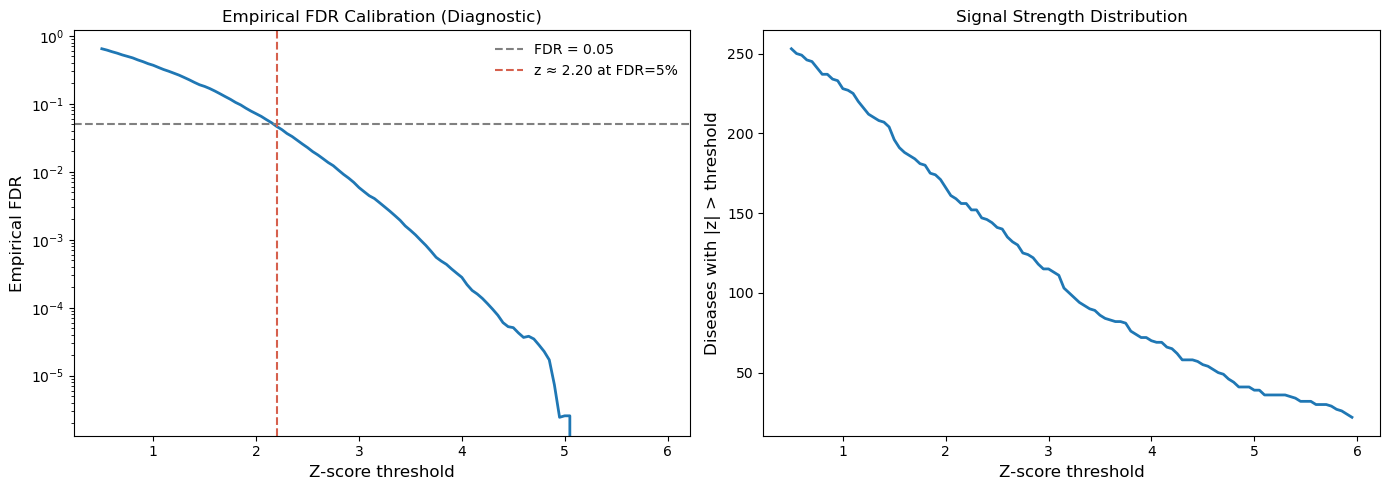

Saved: data/output/fdr_calibration_empirical.png

→ Proceed to  3_spaceflight_disease_visualization.ipynb


In [7]:
Z_THRESHOLDS = np.arange(0.5, 6.0, 0.05)

z_obs   = np.array(list(separation_results["z_score"].values()))
n_total = len(z_obs)
nd_vals = [
    v for v in separation_results["null_distribution"].values()
    if v is not None and hasattr(v, "__len__") and len(v) > 0
]
n_iter = len(nd_vals[0]) if nd_vals else 0
if n_iter == 0:
    print("⚠️  Could not determine n_iter from null distributions — FDR curve may be unreliable.")

print(f"n diseases : {n_total}")
print(f"n_iter     : {n_iter}")

all_null_z = []
for d in separation_results["z_score"]:
    null_dist = separation_results["null_distribution"].get(d)
    if null_dist is None or len(null_dist) == 0:
        continue
    mu    = separation_results["d_mu"][d]
    sigma = separation_results["d_sigma"][d]
    if sigma == 0:
        continue
    all_null_z.append((np.array(null_dist) - mu) / sigma)
all_null_z = np.array(all_null_z)

fdr_curve, n_pos_curve = [], []
for z_t in Z_THRESHOLDS:
    n_pos       = np.sum(np.abs(z_obs) > z_t)
    null_exceed = np.sum(np.abs(all_null_z) > z_t)
    exp_fp      = null_exceed / n_iter if n_iter > 0 else 0
    fdr_curve.append(min(exp_fp / max(n_pos, 1), 1.0))
    n_pos_curve.append(n_pos)

fdr_curve   = np.array(fdr_curve)
n_pos_curve = np.array(n_pos_curve)

FDR_TARGET = 0.05
idx_below  = np.where(fdr_curve <= FDR_TARGET)[0]
EMPIRICAL_Z_THRESH = None

if len(idx_below) > 0:
    EMPIRICAL_Z_THRESH = float(Z_THRESHOLDS[idx_below[0]])
    print(f"\nEmpirical z at FDR 5%: {EMPIRICAL_Z_THRESH:.2f}")
else:
    print("FDR never falls below 5% in tested range.")

# ── Persist to benchmark.json ─────────────────────────────────────────────────
if os.path.exists(BENCH_PATH):
    with open(BENCH_PATH) as f:
        bench_cfg = json.load(f)
    bench_cfg["empirical_z_thresh"] = EMPIRICAL_Z_THRESH
    with open(BENCH_PATH, "w") as f:
        json.dump(bench_cfg, f, indent=2)
    print(f"benchmark.json updated with empirical_z_thresh={EMPIRICAL_Z_THRESH}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].semilogy(Z_THRESHOLDS, fdr_curve, lw=2)
axes[0].axhline(FDR_TARGET, ls="--", lw=1.5, color="grey", label=f"FDR = {FDR_TARGET}")
if EMPIRICAL_Z_THRESH is not None:
    axes[0].axvline(EMPIRICAL_Z_THRESH, ls="--", lw=1.5, color="#d6604d",
                    label=f"z ≈ {EMPIRICAL_Z_THRESH:.2f} at FDR=5%")
axes[0].set_xlabel("Z-score threshold", fontsize=12)
axes[0].set_ylabel("Empirical FDR", fontsize=12)
axes[0].set_title("Empirical FDR Calibration (Diagnostic)", fontsize=12)
axes[0].legend(frameon=False)

axes[1].plot(Z_THRESHOLDS, n_pos_curve, lw=2)
axes[1].set_xlabel("Z-score threshold", fontsize=12)
axes[1].set_ylabel("Diseases with |z| > threshold", fontsize=12)
axes[1].set_title("Signal Strength Distribution", fontsize=12)

plt.tight_layout()
out_path = "data/output/fdr_calibration_empirical.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")
print("\n→ Proceed to  3_spaceflight_disease_visualization.ipynb")


## Step 5 — Summary Statistics

In [8]:
print(f"{'=' * 60}")
print("SEPARATION ANALYSIS SUMMARY  (FDR-driven)")
print(f"Query module : {QUERY_KEY} ({len(query_genes)} genes in PPI)")
print(f"Interactome  : PCNet 2.2 ({ppi.number_of_nodes():,} nodes, {ppi.number_of_edges():,} edges)")
print(f"{'=' * 60}")
print(f"Total diseases compared : {len(results)}")
print()

print("── Classification (FDR < 0.05 + sign of z) ──")
print(f"  Overlapping (sig & z < 0) : {(results['relationship'] == 'Overlapping').sum()}")
print(f"  Neutral  (not sig)        : {(results['relationship'] == 'Neutral').sum()}")
print(f"  Separated (sig & z > 0)   : {(results['relationship'] == 'Separated').sum()}")
print()

print("── Multiple testing ─────────────────────────")
print(f"  BH-FDR significant (p_adj_fdr < 0.05)    : {(results['p_adj_fdr'] < 0.05).sum()}")
print(f"  Bonferroni significant (p_adj_bonf < 0.05): {(results['p_adj_bonf'] < 0.05).sum()}")
print()

print("── Effect size distribution ─────────────────")
print(f"  Median z-score  : {results['z_score'].median():.3f}")
print(f"  Median s_AB     : {results['separation'].median():.3f}")
print()

print("── Gene set size bias ───────────────────────")
r_size, p_size = stats.pearsonr(results["n_genes"], results["z_score"])
print(f"  Pearson r(n_genes, z_score) : {r_size:.3f}  (p = {p_size:.4f})")
if abs(r_size) > 0.3 and p_size < 0.05:
    print("  ⚠️  Moderate size bias detected.")
else:
    print("  ✅ No strong gene set size bias.")
print()

print("── Per-size-bin breakdown ───────────────────")
results["size_bin"] = pd.cut(
    results["n_genes"],
    bins=[0, 50, 150, 99999],
    labels=["Small (≤50 genes)", "Medium (51–150 genes)", "Large (>150 genes)"],
)
summary_bins = results.groupby("size_bin", observed=True).agg(
    n_diseases    = ("z_score",      "count"),
    median_z      = ("z_score",      "median"),
    median_sAB    = ("separation",   "median"),
    n_overlapping = ("relationship", lambda x: (x == "Overlapping").sum()),
    n_separated   = ("relationship", lambda x: (x == "Separated").sum()),
).reset_index()
print(summary_bins.to_string(index=False))
print()

print("── Top 10 most overlapping (lowest z) ──────")
print(results.nsmallest(10, "z_score")[
    ["disease", "z_score", "separation", "n_genes", "p_adj_fdr"]
].to_string(index=False))
print()

print("── Top 10 most separated (highest z) ───────")
print(results.nlargest(10, "z_score")[
    ["disease", "z_score", "separation", "n_genes", "p_adj_fdr"]
].to_string(index=False))


SEPARATION ANALYSIS SUMMARY  (FDR-driven)
Query module : spaceflight (1166 genes in PPI)
Interactome  : PCNet 2.2 (18,554 nodes, 3,323,926 edges)
Total diseases compared : 265

── Classification (FDR < 0.05 + sign of z) ──
  Overlapping (sig & z < 0) : 0
  Neutral  (not sig)        : 109
  Separated (sig & z > 0)   : 156

── Multiple testing ─────────────────────────
  BH-FDR significant (p_adj_fdr < 0.05)    : 156
  Bonferroni significant (p_adj_bonf < 0.05): 77

── Effect size distribution ─────────────────
  Median z-score  : 2.645
  Median s_AB     : 0.321

── Gene set size bias ───────────────────────
  Pearson r(n_genes, z_score) : -0.047  (p = 0.4489)
  ✅ No strong gene set size bias.

── Per-size-bin breakdown ───────────────────
             size_bin  n_diseases  median_z  median_sAB  n_overlapping  n_separated
    Small (≤50 genes)         116  2.635693    0.450744              0           69
Medium (51–150 genes)          80  2.568154    0.291495              0           47
